# Графы для всех лет для прослеживания динамики

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

In [2]:
table = pd.read_csv("./data/data_for_graphs.csv", index_col=0)

In [3]:
# список всех акций
all_nodes = set()
for pair in table.index:
  a, b = pair.strip('()').split(', ')
  all_nodes.add(a)
  all_nodes.add(b)

# для отрисовки
years = [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012]
edge_styles = {
    1: {'color': 'blue', 'style': 'solid', 'width': 1.5},
    -1: {'color': 'none', 'style': 'none', 'width': 0},
    0: {'color': 'gray', 'style': 'dashed', 'width': 1.0, 'alpha': 0.5}
}

Таблица, на основе которой будут строиться графы:

In [4]:
table

,2005,2006,2007,2008,2009,2010,2011,2012
pairs,,,,,,,,
"(ADS.DE, BEI.DE)",0,1,1,1,1,1,1,1
"(ADS.DE, BMW.DE)",0,1,1,1,1,1,1,1
"(ADS.DE, CON.DE)",1,1,1,1,1,1,1,1
"(ADS.DE, DHL.DE)",1,1,1,1,1,1,1,1
"(ADS.DE, FME.DE)",1,1,1,1,0,1,1,1
"(ADS.DE, FRE.DE)",0,1,1,1,0,0,1,1
"(ADS.DE, HEN3.DE)",1,1,1,1,1,1,1,1
"(ADS.DE, MRK.DE)",1,1,0,1,0,0,1,1
"(ADS.DE, TKA.DE)",1,1,1,1,1,1,1,1



*   Синие ребра означают значимую связь между акциями;
*   Отсутствие связи - отсутствие ребра;
*   Пунктирная серая линия означает неопределенность.


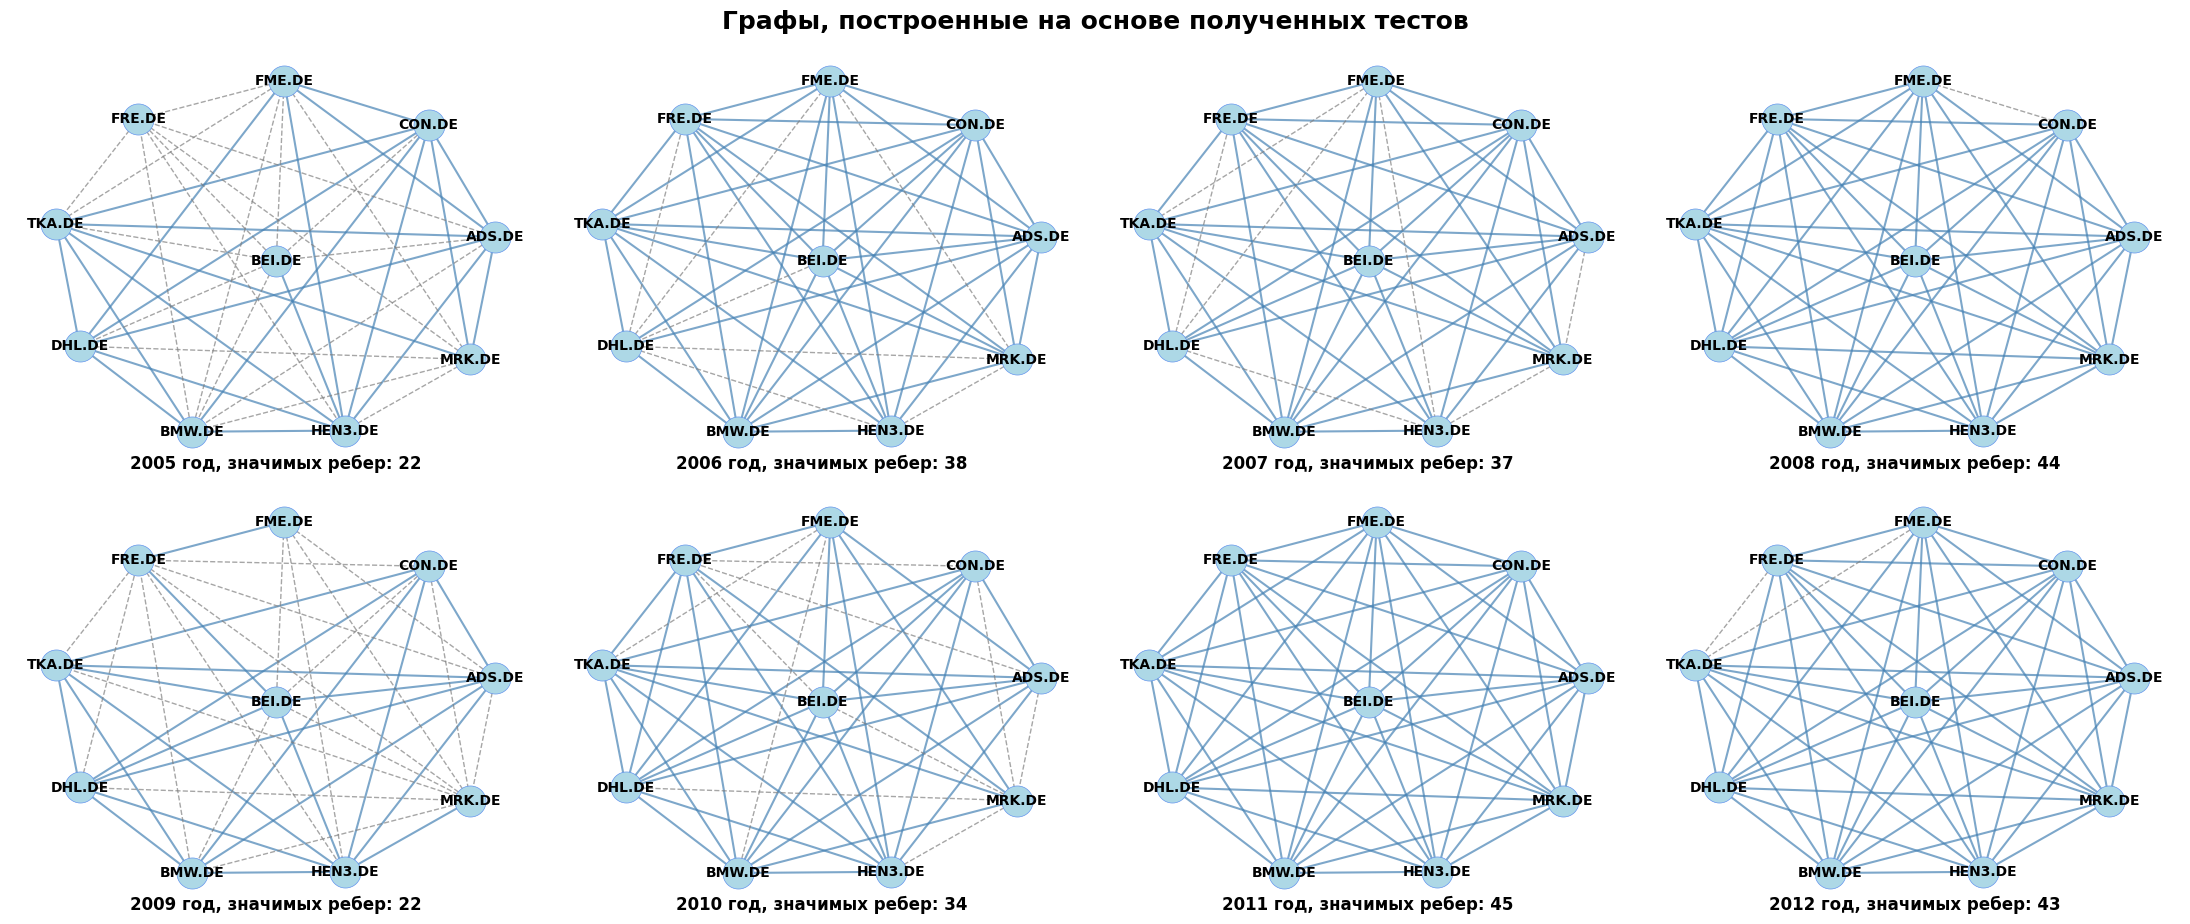

In [5]:
# отрисовка графов
fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(22, 10))
fig.suptitle('Графы, построенные на основе полученных тестов', fontsize=18, fontweight='bold')

# позиции вершин для всех графов будут одинаковыми
G_full = nx.Graph()
G_full.add_nodes_from(all_nodes)
all_pairs = [pair.strip('()').split(', ') for pair in table.index]
for a, b in all_pairs:
    G_full.add_edge(a.strip(), b.strip())

pos = nx.spring_layout(G_full, seed=42, k=2, iterations=50)

axes_flat = axes.flatten()
for i, year in enumerate(years):
    ax = axes_flat[i]

    G = nx.Graph()
    G.add_nodes_from(all_nodes)

    edges_pos = []
    edges_zero = []

    for pair in table.index:
        clean_pair = pair.strip('()')
        a, b = [x.strip() for x in clean_pair.split(',')]

        value = table.loc[pair, str(year)]

        if value == 1:
            edges_pos.append((a, b))
        elif value == 0:
            edges_zero.append((a, b))

    G.add_edges_from(edges_pos)
    G.add_edges_from(edges_zero)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=500, node_color='#ADD8E6',
                          edgecolors='#6495ED', linewidths=0.5)

    if edges_pos:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges_pos,
                               edge_color='#4682B4', width=1.5, style='solid', alpha=0.7)
    if edges_zero:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges_zero,
                               edge_color='gray', width=1.0, style='dashed', alpha=0.7)

    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight='bold')
    ax.set_title(f'{year} год, значимых ребер: {len(edges_pos)}',
                 fontsize=12, fontweight='bold', loc='center', y=-0.02)
    ax.set_facecolor('#f5f5f5')
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('./data/market_graphs_germany.png', dpi=150, bbox_inches='tight')
plt.show()